# Environment and local-module imports

In [1]:
# ============================================================
# Cell 1
# Environment and local-module imports
# ============================================================

from pathlib import Path
import importlib
import json
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd()

required_files = [
    PROJECT_ROOT / "QWZmodel.py",
    PROJECT_ROOT / "finite_scaling.py",
    PROJECT_ROOT / "exponents.py",
]

missing_files = [
    path.name
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing required project files:\n- "
        + "\n- ".join(missing_files)
    )

project_string = str(PROJECT_ROOT.resolve())

if project_string not in sys.path:
    sys.path.insert(0, project_string)


import QWZmodel
import finite_scaling
import exponents

importlib.reload(QWZmodel)
importlib.reload(finite_scaling)
importlib.reload(exponents)


from QWZmodel import QWZModel
import finite_scaling as fs
import exponents as ex


print("Loaded modules")
print("QWZmodel.py:      ", Path(QWZmodel.__file__).resolve())
print("finite_scaling.py:", Path(finite_scaling.__file__).resolve())
print("exponents.py:     ", Path(exponents.__file__).resolve())


plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)

Loaded modules
QWZmodel.py:       C:\Users\mli826\Github_rep\disorder-driven-topological-transition-new\disorder-driven-topological-transition\QWZmodel.py
finite_scaling.py: C:\Users\mli826\Github_rep\disorder-driven-topological-transition-new\disorder-driven-topological-transition\finite_scaling.py
exponents.py:      C:\Users\mli826\Github_rep\disorder-driven-topological-transition-new\disorder-driven-topological-transition\exponents.py


# Project configuration & File I/O and metadata protection

In [22]:
# ============================================================
# Cell 2
# Project configuration
#
# This is the main cell to edit for a new calculation.
# ============================================================

DEMO_MODE = False


# ------------------------------------------------------------
# Project and output labels
# ------------------------------------------------------------

PROJECT_NAME = "qwz_bott_sbatch1"
BOUNDARY_LABEL = "left_impurity_boundary"

OUT_DIR = Path(PROJECT_NAME)
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# QWZ Hamiltonian
# ------------------------------------------------------------

MODEL_PARAMS = {
    "t": 1.0,
    "u": -2.05,
    "A": 1.5,
}

FERMI_ENERGY = 0.0


# ------------------------------------------------------------
# Disorder ensemble
# ------------------------------------------------------------

DENSITY = 0.03

# Options:
#     "fixed_count"
#     "bernoulli"
ENSEMBLE = "fixed_count"

# Relevant only for fixed_count
ROUNDING = "round"


# ------------------------------------------------------------
# Bott finite-size scan
# ------------------------------------------------------------

if DEMO_MODE:

    # These sizes are deliberately small.
    # They test the pipeline, not the physical asymptotic exponent.
    L_VALUES = [8, 10, 12]

    H_VALUES = np.linspace(
        -3.52,
        -3.36,
        9,
    )

    N_BOTT_REALIZATIONS = 6
    BOTT_BOOTSTRAP = 20
    BOTT_POLYNOMIAL_ORDER = 1

else:

    # Replace these with production values.
    L_VALUES = [20, 30, 40, 50, ]

    # H_VALUES = np.linspace(
    #     -3.48,
    #     -3.40,
    #     17,
    # )
    H_VALUES = np.array([
    -3.456,
    -3.454,
    -3.452,
    -3.450,
    -3.448,
    -3.446,
    -3.444,])

    N_BOTT_REALIZATIONS = 200
    BOTT_BOOTSTRAP = 0
    BOTT_POLYNOMIAL_ORDER = 3


BOTT_SEED0 = 20260725


# ------------------------------------------------------------
# Spectral and wavefunction scan at the estimated critical point
# ------------------------------------------------------------

# It is legal for these sizes to differ from the Bott sizes.
SPECTRAL_L_VALUES = list(L_VALUES)

if DEMO_MODE:
    N_SPECTRAL_REALIZATIONS = 6
    MULTIFRACTAL_BOOTSTRAP = 20
else:
    N_SPECTRAL_REALIZATIONS = 100
    MULTIFRACTAL_BOOTSTRAP = 500

SPECTRAL_SEED0 = 20260726


# Critical-point selection:
#
#   "fit"    -> use h_c from the Bott fit
#   "manual" -> use HC_MANUAL
#
# For production use "fit" only after the Bott fit is stable.
HC_SOURCE = "fit"
HC_MANUAL = -3.445


# ------------------------------------------------------------
# DOS settings
# ------------------------------------------------------------

# Gaussian broadening used to turn finite eigenvalues into a smooth DOS.
DOS_BROADENING = 0.035

DOS_ENERGY_GRID = np.geomspace(
    0.02,
    0.35,
    36,
)

# This should later be selected from a visible scaling window.
DOS_FIT_WINDOW = (
    0.06,
    0.25,
)

DOS_BOOTSTRAP = 20 if DEMO_MODE else 500


# ------------------------------------------------------------
# Multifractal settings
# ------------------------------------------------------------

Q_VALUES = np.array(
    [
        0.5,
        1.5,
        2.0,
        2.5,
        3.0,
    ],
    dtype=float,
)

# First version uses one lattice site per box.
#
# For a final left-boundary analysis, the box size should eventually
# also be tested above the mean impurity spacing.
MULTIFRACTAL_BOX_SIZE = 1


# ------------------------------------------------------------
# Run/load switches
# ------------------------------------------------------------

RUN_BOTT_SIMULATION = False
RUN_SPECTRAL_SIMULATION = False

# Set True only when intentionally reusing a folder with
# incompatible parameters.
ALLOW_METADATA_MISMATCH = False


# ------------------------------------------------------------
# Show configuration
# ------------------------------------------------------------

print("Boundary:", BOUNDARY_LABEL)
print("L values:", L_VALUES)
print("h range:", (float(H_VALUES.min()), float(H_VALUES.max())))
print("Bott realizations per point:", N_BOTT_REALIZATIONS)
print("Spectral realizations per size:", N_SPECTRAL_REALIZATIONS)
print("Disorder ensemble:", ENSEMBLE)
print("Target density:", DENSITY)

print("\nImportant:")
print(
    "DEMO_MODE=True tests code flow only; "
    "its fitted exponents are not production physics."
)

# ============================================================
# Cell 3
# File I/O and metadata protection
# ============================================================

BOTT_RAW_CSV = OUT_DIR / "bott_raw.csv"
BOTT_SUMMARY_CSV = OUT_DIR / "bott_summary.csv"

SPECTRUM_RAW_CSV = OUT_DIR / "spectrum_raw.csv"
STATE_RAW_CSV = OUT_DIR / "critical_state_raw.csv"
MULTIFRACTAL_RAW_CSV = OUT_DIR / "multifractal_raw.csv"

DOS_RAW_CSV = OUT_DIR / "dos_raw.csv"
DOS_SUMMARY_CSV = OUT_DIR / "dos_summary.csv"

RUN_METADATA_JSON = OUT_DIR / "run_metadata.json"


RUN_CONFIG = {
    "project_name": PROJECT_NAME,
    "boundary_label": BOUNDARY_LABEL,
    "model_params": MODEL_PARAMS,
    "fermi_energy": FERMI_ENERGY,
    "density": DENSITY,
    "ensemble": ENSEMBLE,
    "rounding": ROUNDING,
    "L_values": [int(x) for x in L_VALUES],
    "h_values": [float(x) for x in H_VALUES],
    "n_bott_realizations": int(N_BOTT_REALIZATIONS),
    "bott_seed0": int(BOTT_SEED0),
    "spectral_L_values": [
        int(x)
        for x in SPECTRAL_L_VALUES
    ],
    "n_spectral_realizations": int(N_SPECTRAL_REALIZATIONS),
    "spectral_seed0": int(SPECTRAL_SEED0),
    "dos_broadening": float(DOS_BROADENING),
    "dos_energy_grid": [
        float(x)
        for x in DOS_ENERGY_GRID
    ],
    "q_values": [
        float(x)
        for x in Q_VALUES
    ],
    "multifractal_box_size": int(MULTIFRACTAL_BOX_SIZE),
}


if RUN_METADATA_JSON.exists():

    with RUN_METADATA_JSON.open(
        "r",
        encoding="utf-8",
    ) as handle:
        old_config = json.load(handle)

    if (
        old_config != RUN_CONFIG
        and not ALLOW_METADATA_MISMATCH
    ):
        raise RuntimeError(
            "The output folder already contains data generated with "
            "a different configuration.\n\n"
            "Use a new PROJECT_NAME, delete the old output folder, "
            "or explicitly set ALLOW_METADATA_MISMATCH=True."
        )

else:

    with RUN_METADATA_JSON.open(
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            RUN_CONFIG,
            handle,
            indent=2,
            sort_keys=True,
        )


print("Output directory:", OUT_DIR.resolve())

for path in [
    BOTT_RAW_CSV,
    BOTT_SUMMARY_CSV,
    SPECTRUM_RAW_CSV,
    STATE_RAW_CSV,
    MULTIFRACTAL_RAW_CSV,
    DOS_RAW_CSV,
    DOS_SUMMARY_CSV,
]:
    print(path.name)

Boundary: left_impurity_boundary
L values: [20, 30, 40, 50]
h range: (-3.456, -3.444)
Bott realizations per point: 200
Spectral realizations per size: 100
Disorder ensemble: fixed_count
Target density: 0.03

Important:
DEMO_MODE=True tests code flow only; its fitted exponents are not production physics.
Output directory: C:\Users\mli826\Github_rep\disorder-driven-topological-transition-new\disorder-driven-topological-transition\qwz_bott_sbatch1
bott_raw.csv
bott_summary.csv
spectrum_raw.csv
critical_state_raw.csv
multifractal_raw.csv
dos_raw.csv
dos_summary.csv


# Setupt & run

In [24]:
# ============================================================
# Cell 4
# Construct the actual QWZ model
# ============================================================

template_model = QWZModel(
    Lx=L_VALUES[0],
    Ly=L_VALUES[0],
    pbc=True,
    **MODEL_PARAMS,
)


print("Model parameters")
print("t =", template_model.t)
print("u =", template_model.u)
print("A =", template_model.A)

print("\nHamiltonian blocks")
print("onsite =")
print(template_model.onsite_block)

print("\nhopping_x =")
print(template_model.hopping_x)

print("\nhopping_y =")
print(template_model.hopping_y)

print("\nimpurity block at h=-3.45 =")
print(template_model.impurity_block(-3.45))


density_rows = []

for L in L_VALUES:

    n_imp = fs.impurity_count_from_density(
        L * L,
        DENSITY,
        rounding=ROUNDING,
    )

    density_rows.append(
        {
            "L": L,
            "L^2": L * L,
            "N_imp_fixed_count": n_imp,
            "p_eff_fixed_count": n_imp / (L * L),
            "p_target": DENSITY,
        }
    )

density_table = pd.DataFrame(density_rows)

display(density_table)


gamma_energies = template_model.dispersion(
    0.0,
    0.0,
)

print(
    "Clean Gamma-point energies:",
    gamma_energies,
)

print(
    "Clean Gamma mass u+2t =",
    template_model.u
    + 2.0 * template_model.t,
)


# ============================================================
# Cell 5
# Run or load the checkpointable Bott scan
# ============================================================

start_time = time.perf_counter()


if RUN_BOTT_SIMULATION:

    bott_raw, bott_summary = fs.run_bott_scan(
        sizes=L_VALUES,
        h_values=H_VALUES,
        template=template_model,
        density=DENSITY,
        n_realizations=N_BOTT_REALIZATIONS,
        ensemble=ENSEMBLE,
        seed0=BOTT_SEED0,
        rounding=ROUNDING,
        fermi_energy=FERMI_ENERGY,
        raw_csv=BOTT_RAW_CSV,
        summary_csv=BOTT_SUMMARY_CSV,
        boundary_label=BOUNDARY_LABEL,
        verbose=True,
    )

else:

    if (
        not BOTT_RAW_CSV.exists()
        or not BOTT_SUMMARY_CSV.exists()
    ):
        raise FileNotFoundError(
            "RUN_BOTT_SIMULATION=False, but Bott CSV files "
            "do not exist."
        )

    bott_raw = pd.read_csv(
        BOTT_RAW_CSV
    )

    bott_summary = pd.read_csv(
        BOTT_SUMMARY_CSV
    )


elapsed = time.perf_counter() - start_time

print()
print(
    f"Bott stage finished in {elapsed:.2f} s"
)

print(
    f"Raw rows: {len(bott_raw)}"
)

print(
    f"Summary rows: {len(bott_summary)}"
)

display(
    bott_summary.sort_values(
        ["L", "h"]
    )
)

Model parameters
t = 1.0
u = -2.05
A = 1.5

Hamiltonian blocks
onsite =
[[-2.05+0.j -0.  +0.j]
 [-0.  +0.j  2.05-0.j]]

hopping_x =
[[ 0.5+0.j    0. +0.75j]
 [ 0. +0.75j -0.5+0.j  ]]

hopping_y =
[[ 0.5 +0.j  0.75+0.j]
 [-0.75+0.j -0.5 +0.j]]

impurity block at h=-3.45 =
[[ 3.45+0.j  0.  +0.j]
 [ 0.  +0.j -3.45+0.j]]


,L,L^2,N_imp_fixed_count,p_eff_fixed_count,p_target
0,20,400,12,0.03,0.03
1,30,900,27,0.03,0.03
2,40,1600,48,0.03,0.03
3,50,2500,75,0.03,0.03


Clean Gamma-point energies: [-0.05  0.05]
Clean Gamma mass u+2t = -0.04999999999999982

Bott stage finished in 0.02 s
Raw rows: 5600
Summary rows: 28


,Lx,Ly,h,ensemble,p_target,boundary,t,u,A,n,...,P_B0,mean_B_float,max_integer_residual,mean_p_eff,std_p_eff,mean_gap,median_min_abs_energy,mean_runtime_sec,P_absB1_sem_binomial,L
0,20,20,-3.456,fixed_count,0.03,left_impurity_boundary,1.0,-2.05,1.5,200,...,0.755,0.245,1.249251e-14,0.03,0.0,0.010523,0.004002,1.886499,0.030412,20.0
1,20,20,-3.454,fixed_count,0.03,left_impurity_boundary,1.0,-2.05,1.5,200,...,0.750,0.250,1.279290e-14,0.03,0.0,0.010293,0.003429,1.882891,0.030619,20.0
2,20,20,-3.452,fixed_count,0.03,left_impurity_boundary,1.0,-2.05,1.5,200,...,0.720,0.280,1.313746e-14,0.03,0.0,0.011869,0.004580,1.885026,0.031749,20.0
3,20,20,-3.450,fixed_count,0.03,left_impurity_boundary,1.0,-2.05,1.5,200,...,0.595,0.405,9.303122e-15,0.03,0.0,0.010476,0.003632,1.886359,0.034711,20.0
4,20,20,-3.448,fixed_count,0.03,left_impurity_boundary,1.0,-2.05,1.5,200,...,0.595,0.405,1.432133e-14,0.03,0.0,0.009702,0.003116,2.008379,0.034711,20.0
5,20,20,-3.446,fixed_count,0.03,left_impurity_boundary,1.0,-2.05,1.5,200,...,0.470,0.530,1.798561e-14,0.03,0.0,0.011270,0.003976,2.540139,0.035292,20.0
6,20,20,-3.444,fixed_count,0.03,left_impurity_boundary,1.0,-2.05,1.5,200,...,0.480,0.520,1.299610e-14,0.03,0.0,0.011647,0.004323,2.514557,0.035327,20.0
7,30,30,-3.456,fixed_count,0.03,left_impurity_boundary,1.0,-2.05,1.5,200,...,0.840,0.160,1.408279e-14,0.03,0.0,0.011212,0.004573,9.730507,0.025923,30.0
8,30,30,-3.454,fixed_count,0.03,left_impurity_boundary,1.0,-2.05,1.5,200,...,0.815,0.185,1.609935e-14,0.03,0.0,0.010275,0.004324,9.736736,0.027457,30.0
9,30,30,-3.452,fixed_count,0.03,left_impurity_boundary,1.0,-2.05,1.5,200,...,0.700,0.300,1.512089e-14,0.03,0.0,0.011207,0.004806,9.720035,0.032404,30.0


# Critical Exponent

Primary binomial-likelihood result


,parameter,estimate,standard_error,ci_low,ci_high
0,hc,-3.450636,0.000836,-3.452275,-3.448998
1,nu,1.543882,0.319591,0.917494,2.170269
2,c0,-0.676042,0.140560,-0.951535,-0.400550
3,c1,16.838386,8.158776,0.847479,32.829293
4,c2,-7.446520,6.729683,-20.636457,5.743416
5,c3,-8.655976,0.184173,-9.016949,-8.295004


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

Fit success: True
Optimizer message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


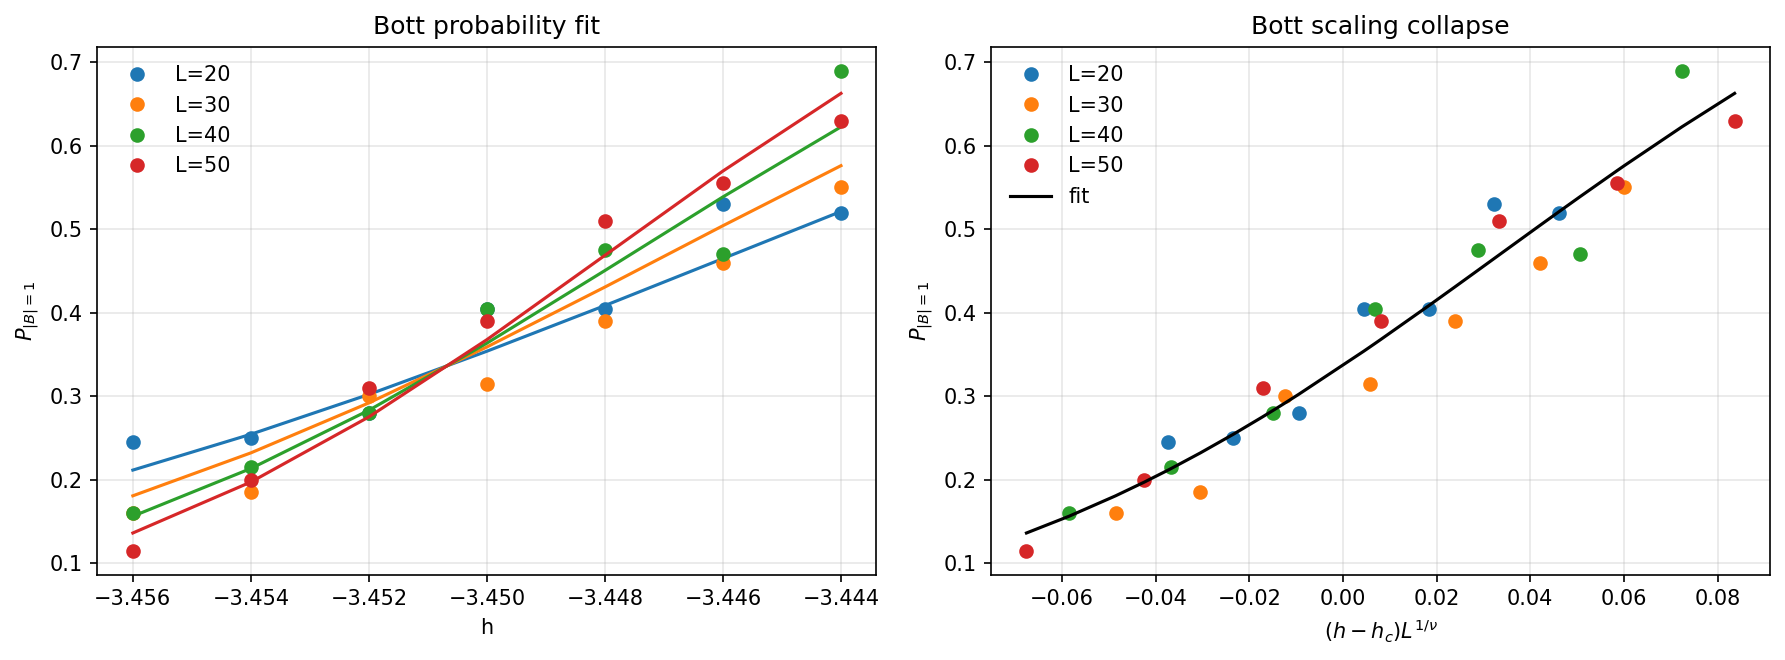


Bott estimate:
hc = -3.45063631
nu = 1.543882


C:\Users\mli826\AppData\Local\Temp\ipykernel_54168\2339452203.py:96: UserWarning: Width diagnostic could not be extracted from this small data set: at least two valid Bott widths are required
  warnings.warn(


In [26]:
# ============================================================
# Cell 7
# Critical exponent nu from Bott probability
# ============================================================

bott_fit_config = ex.BottNuConfig(
    size_col="L",
    h_col="h",
    outcome_col="abs_bott",

    min_size=min(L_VALUES),

    h_window=(
        float(H_VALUES.min()),
        float(H_VALUES.max()),
    ),

    polynomial_order=BOTT_POLYNOMIAL_ORDER,

    hc_bounds=(
        float(H_VALUES.min()),
        float(H_VALUES.max()),
    ),

    nu_bounds=(
        0.2,
        6.0,
    ),

    n_bootstrap=BOTT_BOOTSTRAP,
    confidence_level=0.95,
    seed=20260727,
)


bott_fit_result = ex.fit_nu_from_bott(
    bott_raw,
    config=bott_fit_config,
)


print("Primary binomial-likelihood result")
display(
    bott_fit_result.summary_frame()
)

print(
    "Fit success:",
    bott_fit_result.success,
)

print(
    "Optimizer message:",
    bott_fit_result.message,
)


ex.plot_bott_nu_result(
    bott_fit_result
)

plt.show()


# ------------------------------------------------------------
# Width-based diagnostic
# ------------------------------------------------------------

try:

    bott_width_result = (
        ex.diagnose_bott_width_scaling(
            bott_raw,
            config=bott_fit_config,
        )
    )

    print(
        "\nWidth-scaling diagnostic"
    )

    display(
        bott_width_result.summary_frame()
    )

    display(
        bott_width_result.metadata[
            "width_table"
        ]
    )

except Exception as error:

    bott_width_result = None

    warnings.warn(
        "Width diagnostic could not be extracted from "
        f"this small data set: {error}"
    )


# ------------------------------------------------------------
# Save fit outputs
# ------------------------------------------------------------

bott_fit_result.summary_frame().to_csv(
    OUT_DIR / "bott_nu_fit_summary.csv",
    index=False,
)

bott_fit_result.predictions.to_csv(
    OUT_DIR / "bott_nu_predictions.csv",
    index=False,
)

bott_fit_result.residuals.to_csv(
    OUT_DIR / "bott_nu_residuals.csv",
    index=False,
)

if bott_fit_result.bootstrap_samples is not None:

    bott_fit_result.bootstrap_samples.to_csv(
        OUT_DIR / "bott_nu_bootstrap.csv",
        index=False,
    )


print()
print(
    "Bott estimate:"
)

print(
    f"hc = {bott_fit_result.parameters['hc']:.8f}"
)

print(
    f"nu = {bott_fit_result.parameters['nu']:.6f}"
)

if DEMO_MODE:
    print(
        "\nThis is a small-size pipeline result, "
        "not a physical universality estimate."
    )

Bott probability table:


,L,h,n,k,p,p_err
0,20,-3.456,200,49,0.245,0.030412
1,20,-3.454,200,50,0.250,0.030619
2,20,-3.452,200,56,0.280,0.031749
3,20,-3.450,200,81,0.405,0.034711
4,20,-3.448,200,81,0.405,0.034711
5,20,-3.446,200,106,0.530,0.035292
6,20,-3.444,200,104,0.520,0.035327
7,30,-3.456,200,32,0.160,0.025923
8,30,-3.454,200,37,0.185,0.027457
9,30,-3.452,200,60,0.300,0.032404


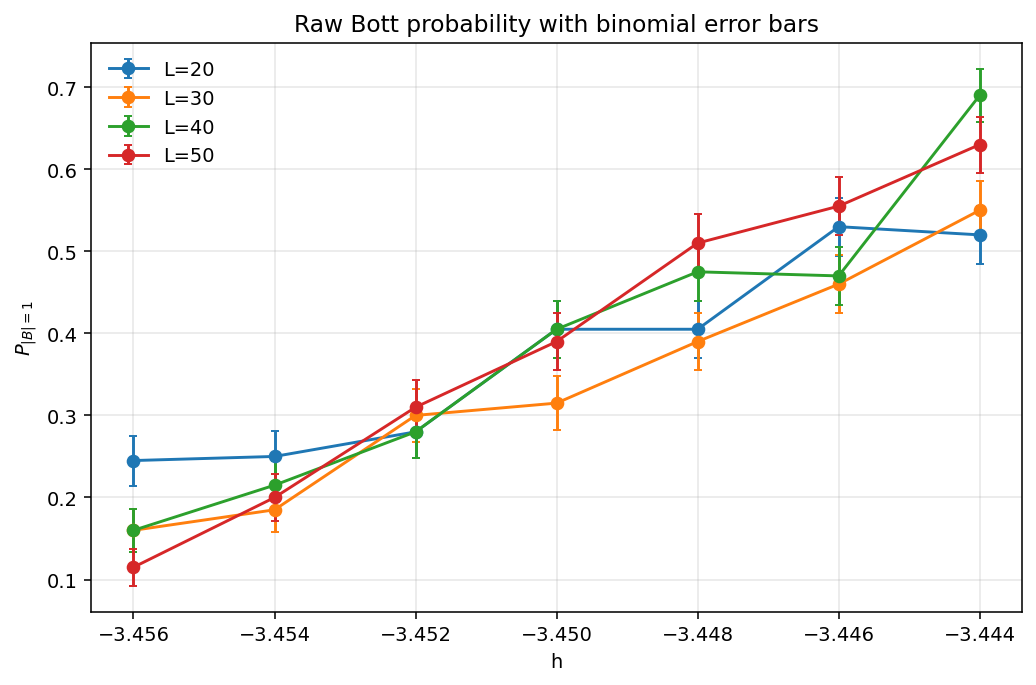


Bott-fit stability study


,min_size,polynomial_order,success,hc,nu,message
0,20,1,True,-3.450556,1.661891,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,20,2,True,-3.450968,1.539212,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
2,20,3,True,-3.450636,1.543882,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
3,30,1,True,-3.454368,1.901723,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
4,30,2,True,-3.453788,1.411811,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
5,30,3,True,-3.453793,1.401489,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...



Primary binomial-likelihood result
Using L >= 30
Polynomial order = 1


,parameter,estimate,standard_error,ci_low,ci_high
0,hc,-3.454368,0.001681,-3.457662,-3.451073
1,nu,1.901723,0.048044,1.807558,1.995887
2,c0,-1.388281,0.299253,-1.974806,-0.801756
3,c1,26.108699,0.004956,26.098985,26.118413


Fit success: True
Optimizer message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


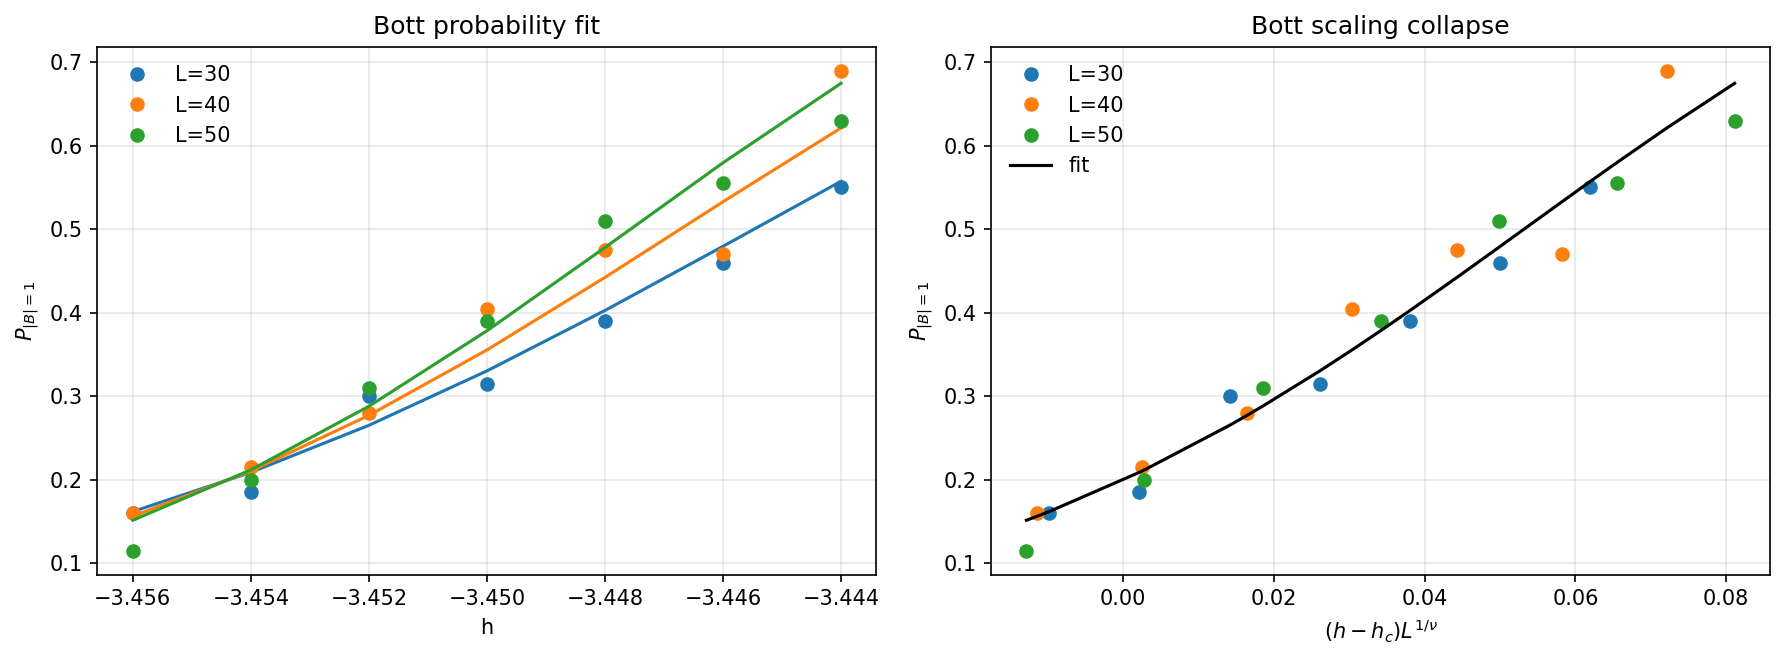


Bott estimate
hc = -3.45436753
nu = 1.901723


C:\Users\mli826\AppData\Local\Temp\ipykernel_54168\3807116020.py:290: UserWarning: Width diagnostic could not be extracted: at least two valid Bott widths are required
  warnings.warn(


In [30]:
# ============================================================
# Cell 7
# Critical exponent nu from Bott probability
#
# Strategy:
#   1. Primary fit: drop L=20 and use a linear scaling function.
#   2. Run a small stability study versus:
#          L_min = 20, 30
#          polynomial order = 1, 2, 3
#   3. Bootstrap is OFF for now so this cell is fast.
# ============================================================


# ------------------------------------------------------------
# Primary-fit choices
# ------------------------------------------------------------

PRIMARY_MIN_SIZE = 30
PRIMARY_POLYNOMIAL_ORDER = 1

# Keep bootstrap off while diagnosing the fit.
# After the fit strategy is stable, change this to 500.
PRIMARY_BOOTSTRAP = 0


# ------------------------------------------------------------
# Basic probability table + binomial uncertainty
# ------------------------------------------------------------

bott_probability_table = (
    bott_raw
    .groupby(["L", "h"], as_index=False)
    .agg(
        n=("abs_bott", "size"),
        k=("abs_bott", "sum"),
    )
)

bott_probability_table["p"] = (
    bott_probability_table["k"]
    / bott_probability_table["n"]
)

bott_probability_table["p_err"] = np.sqrt(
    bott_probability_table["p"]
    * (1.0 - bott_probability_table["p"])
    / bott_probability_table["n"]
)

print("Bott probability table:")
display(bott_probability_table)


# ------------------------------------------------------------
# Plot raw probability with binomial error bars
# ------------------------------------------------------------

plt.figure(figsize=(7.5, 5.0), dpi=140)

for L, group in bott_probability_table.groupby("L"):

    group = group.sort_values("h")

    plt.errorbar(
        group["h"],
        group["p"],
        yerr=group["p_err"],
        marker="o",
        linestyle="-",
        capsize=2,
        label=f"L={L:g}",
    )

plt.xlabel("h")
plt.ylabel(r"$P_{|B|=1}$")
plt.title("Raw Bott probability with binomial error bars")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


# ============================================================
# Part A
# Stability study
# ============================================================

stability_rows = []

for min_size_test in [20, 30]:

    for order_test in [1, 2, 3]:

        test_config = ex.BottNuConfig(
            size_col="L",
            h_col="h",
            outcome_col="abs_bott",

            min_size=min_size_test,

            h_window=(
                float(H_VALUES.min()),
                float(H_VALUES.max()),
            ),

            polynomial_order=order_test,

            hc_bounds=(
                float(H_VALUES.min()),
                float(H_VALUES.max()),
            ),

            nu_bounds=(
                0.2,
                6.0,
            ),

            # No bootstrap in the stability scan.
            n_bootstrap=0,

            confidence_level=0.95,
            seed=20260727,
        )

        try:

            test_result = ex.fit_nu_from_bott(
                bott_raw,
                config=test_config,
            )

            stability_rows.append(
                {
                    "min_size": min_size_test,
                    "polynomial_order": order_test,
                    "success": test_result.success,
                    "hc": test_result.parameters["hc"],
                    "nu": test_result.parameters["nu"],
                    "message": test_result.message,
                }
            )

        except Exception as error:

            stability_rows.append(
                {
                    "min_size": min_size_test,
                    "polynomial_order": order_test,
                    "success": False,
                    "hc": np.nan,
                    "nu": np.nan,
                    "message": str(error),
                }
            )


stability_table = pd.DataFrame(stability_rows)

print()
print("==========================================")
print("Bott-fit stability study")
print("==========================================")

display(stability_table)

stability_table.to_csv(
    OUT_DIR / "bott_nu_stability_table.csv",
    index=False,
)


# ============================================================
# Part B
# Primary fit
#
# Recommended current choice:
#   L = 30, 40, 50
#   polynomial order = 1
# ============================================================

bott_fit_config = ex.BottNuConfig(
    size_col="L",
    h_col="h",
    outcome_col="abs_bott",

    min_size=PRIMARY_MIN_SIZE,

    h_window=(
        float(H_VALUES.min()),
        float(H_VALUES.max()),
    ),

    polynomial_order=PRIMARY_POLYNOMIAL_ORDER,

    hc_bounds=(
        float(H_VALUES.min()),
        float(H_VALUES.max()),
    ),

    nu_bounds=(
        0.2,
        6.0,
    ),

    n_bootstrap=PRIMARY_BOOTSTRAP,

    confidence_level=0.95,
    seed=20260727,
)


bott_fit_result = ex.fit_nu_from_bott(
    bott_raw,
    config=bott_fit_config,
)


print()
print("==========================================")
print("Primary binomial-likelihood result")
print("==========================================")

print(
    f"Using L >= {PRIMARY_MIN_SIZE}"
)

print(
    "Polynomial order =",
    PRIMARY_POLYNOMIAL_ORDER,
)

display(
    bott_fit_result.summary_frame()
)

print(
    "Fit success:",
    bott_fit_result.success,
)

print(
    "Optimizer message:",
    bott_fit_result.message,
)


# ------------------------------------------------------------
# Primary scaling plot
# ------------------------------------------------------------

ex.plot_bott_nu_result(
    bott_fit_result
)

plt.show()


# ------------------------------------------------------------
# Width-based diagnostic
# ------------------------------------------------------------

try:

    bott_width_result = (
        ex.diagnose_bott_width_scaling(
            bott_raw,
            config=bott_fit_config,
        )
    )

    print()
    print("==========================================")
    print("Width-scaling diagnostic")
    print("==========================================")

    display(
        bott_width_result.summary_frame()
    )

    display(
        bott_width_result.metadata[
            "width_table"
        ]
    )

except Exception as error:

    bott_width_result = None

    warnings.warn(
        "Width diagnostic could not be extracted: "
        f"{error}"
    )


# ------------------------------------------------------------
# Save primary-fit outputs
# ------------------------------------------------------------

bott_fit_result.summary_frame().to_csv(
    OUT_DIR / "bott_nu_fit_summary.csv",
    index=False,
)

bott_fit_result.predictions.to_csv(
    OUT_DIR / "bott_nu_predictions.csv",
    index=False,
)

bott_fit_result.residuals.to_csv(
    OUT_DIR / "bott_nu_residuals.csv",
    index=False,
)

if bott_fit_result.bootstrap_samples is not None:

    bott_fit_result.bootstrap_samples.to_csv(
        OUT_DIR / "bott_nu_bootstrap.csv",
        index=False,
    )


print()
print("==========================================")
print("Bott estimate")
print("==========================================")

print(
    f"hc = {bott_fit_result.parameters['hc']:.8f}"
)

print(
    f"nu = {bott_fit_result.parameters['nu']:.6f}"
)


if DEMO_MODE:

    print(
        "\nThis is a small-size pipeline result, "
        "not a physical universality estimate."
    )

# Dynamic Exponent

In [28]:
# ============================================================
# Cell 8
# Critical eigenspectrum and wavefunction moments
#
# This cell performs real QWZ diagonalizations at h_c.
# It saves eigenvalues and generalized participation ratios,
# but does not save the full eigenvectors.
# ============================================================

hc_fit = float(
    bott_fit_result.parameters["hc"]
)


largest_L = max(L_VALUES)

largest_summary = (
    bott_summary[
        bott_summary["L"] == largest_L
    ]
    .sort_values("h")
    .copy()
)

pseudo_index = (
    largest_summary["P_absB1"]
    - 0.5
).abs().idxmin()

hc_pseudocritical = float(
    largest_summary.loc[
        pseudo_index,
        "h",
    ]
)


if HC_SOURCE == "manual":

    hc_spectral = float(
        HC_MANUAL
    )

elif HC_SOURCE == "fit":

    if (
        np.isfinite(hc_fit)
        and H_VALUES.min()
        <= hc_fit
        <= H_VALUES.max()
    ):
        hc_spectral = hc_fit

    else:
        warnings.warn(
            "The fitted h_c lies outside the simulated h range. "
            "Using the largest-size P≈0.5 point instead."
        )

        hc_spectral = hc_pseudocritical

else:

    raise ValueError(
        "HC_SOURCE must be 'fit' or 'manual'."
    )


print(
    f"Fitted hc:             {hc_fit:.8f}"
)

print(
    f"Largest-size pseudo hc:{hc_pseudocritical:.8f}"
)

print(
    f"Spectral hc used:      {hc_spectral:.8f}"
)


if RUN_SPECTRAL_SIMULATION:

    eigenvalue_rows = []
    state_rows = []
    multifractal_rows = []

    start_time = time.perf_counter()

    for size_index, L in enumerate(
        SPECTRAL_L_VALUES
    ):

        model = QWZModel(
            Lx=L,
            Ly=L,
            pbc=True,
            **MODEL_PARAMS,
        )

        for realization in range(
            N_SPECTRAL_REALIZATIONS
        ):

            seed = fs.make_realization_seed(
                SPECTRAL_SEED0,
                31,
                size_index,
                L,
                realization,
            )

            impurities = fs.sample_impurities(
                model,
                ensemble=ENSEMBLE,
                density=DENSITY,
                seed=seed,
                rounding=ROUNDING,
            )

            Hamiltonian = model.hamiltonian(
                impurities=impurities,
                h=hc_spectral,
                sparse=False,
            )

            eigenvalues, eigenvectors = (
                fs.diagonalize_hermitian(
                    Hamiltonian
                )
            )

            # ----------------------------------------------
            # Save the full finite-size spectrum
            # ----------------------------------------------

            for level_index, energy in enumerate(
                eigenvalues
            ):

                eigenvalue_rows.append(
                    {
                        "L": L,
                        "h": hc_spectral,
                        "realization": realization,
                        "seed": seed,
                        "level_index": level_index,
                        "E": float(energy),
                        "n_impurities": len(impurities),
                        "p_eff": (
                            len(impurities)
                            / model.n_sites
                        ),
                    }
                )

            # ----------------------------------------------
            # Choose the smallest positive-energy state
            # ----------------------------------------------

            positive_indices = np.flatnonzero(
                eigenvalues
                >= FERMI_ENERGY
            )

            if positive_indices.size == 0:
                raise RuntimeError(
                    "No nonnegative eigenvalue found."
                )

            state_index = int(
                positive_indices[
                    np.argmin(
                        eigenvalues[
                            positive_indices
                        ]
                        - FERMI_ENERGY
                    )
                ]
            )

            state_energy = float(
                eigenvalues[state_index]
            )

            state = eigenvectors[
                :,
                state_index,
            ]

            site_probability = (
                ex.site_probabilities(
                    state,
                    norb=model.norb,
                    normalize=True,
                )
            )

            impurity_site_indices = [
                x + L * y
                for x, y in impurities
            ]

            impurity_weight = float(
                np.sum(
                    site_probability[
                        impurity_site_indices
                    ]
                )
            ) if impurity_site_indices else 0.0

            # ----------------------------------------------
            # Generalized participation ratios
            # ----------------------------------------------

            gpr = (
                ex.generalized_participation_ratios(
                    site_probability,
                    q_values=Q_VALUES,
                    shape=(L, L),
                    box_size=MULTIFRACTAL_BOX_SIZE,
                )
            )

            for row in gpr.itertuples(
                index=False
            ):

                multifractal_rows.append(
                    {
                        "L": L,
                        "h": hc_spectral,
                        "realization": realization,
                        "seed": seed,
                        "E_state": state_energy,
                        "q": float(row.q),
                        "Pq": float(row.Pq),
                        "n_boxes": int(row.n_boxes),
                        "box_size": int(row.box_size),
                        "n_impurities": len(impurities),
                        "p_eff": (
                            len(impurities)
                            / model.n_sites
                        ),
                    }
                )

            ipr_row = gpr[
                np.isclose(
                    gpr["q"],
                    2.0,
                )
            ]

            ipr = (
                float(ipr_row["Pq"].iloc[0])
                if not ipr_row.empty
                else np.nan
            )

            state_rows.append(
                {
                    "L": L,
                    "h": hc_spectral,
                    "realization": realization,
                    "seed": seed,
                    "E_state": state_energy,
                    "abs_E_state": abs(
                        state_energy
                    ),
                    "IPR": ipr,
                    "PR": (
                        1.0 / ipr
                        if ipr > 0.0
                        else np.nan
                    ),
                    "impurity_weight": impurity_weight,
                    "n_impurities": len(impurities),
                    "p_eff": (
                        len(impurities)
                        / model.n_sites
                    ),
                }
            )

            print(
                f"[spectral] L={L}, "
                f"r={realization}, "
                f"E={state_energy:+.6e}, "
                f"IPR={ipr:.6e}"
            )

    spectrum_raw = pd.DataFrame(
        eigenvalue_rows
    )

    state_raw = pd.DataFrame(
        state_rows
    )

    multifractal_raw = pd.DataFrame(
        multifractal_rows
    )

    spectrum_raw.to_csv(
        SPECTRUM_RAW_CSV,
        index=False,
    )

    state_raw.to_csv(
        STATE_RAW_CSV,
        index=False,
    )

    multifractal_raw.to_csv(
        MULTIFRACTAL_RAW_CSV,
        index=False,
    )

    elapsed = (
        time.perf_counter()
        - start_time
    )

    print(
        f"\nSpectral stage finished in "
        f"{elapsed:.2f} s"
    )

else:

    required = [
        SPECTRUM_RAW_CSV,
        STATE_RAW_CSV,
        MULTIFRACTAL_RAW_CSV,
    ]

    missing = [
        path.name
        for path in required
        if not path.exists()
    ]

    if missing:
        raise FileNotFoundError(
            "Missing spectral output files:\n- "
            + "\n- ".join(missing)
        )

    spectrum_raw = pd.read_csv(
        SPECTRUM_RAW_CSV
    )

    state_raw = pd.read_csv(
        STATE_RAW_CSV
    )

    multifractal_raw = pd.read_csv(
        MULTIFRACTAL_RAW_CSV
    )


# display(state_raw)

# print(
#     "Spectrum rows:",
#     len(spectrum_raw),
# )

# print(
#     "Multifractal rows:",
#     len(multifractal_raw),
# )
# ============================================================
# Cell 9
# Disorder-averaged DOS and dynamical exponent z
#
# rho(E) is estimated with Gaussian broadening:
#
# rho(E) = 1/(L^2 sqrt(2pi) eta)
#          sum_n exp[-(E-E_n)^2/(2 eta^2)]
#
# The integral over all energies equals 2 states per lattice site.
# ============================================================

dos_rows = []

normalization_constant = (
    np.sqrt(2.0 * np.pi)
    * DOS_BROADENING
)


for (
    L,
    realization,
), group in spectrum_raw.groupby(
    [
        "L",
        "realization",
    ]
):

    eigenvalues = group[
        "E"
    ].to_numpy(dtype=float)

    for energy in DOS_ENERGY_GRID:

        kernel = np.exp(
            -0.5
            * (
                (
                    energy
                    - eigenvalues
                )
                / DOS_BROADENING
            ) ** 2
        )

        rho = float(
            np.sum(kernel)
            / (
                L**2
                * normalization_constant
            )
        )

        dos_rows.append(
            {
                "L": int(L),
                "realization": int(realization),
                "E": float(energy),
                "rho": rho,
            }
        )


dos_raw = pd.DataFrame(
    dos_rows
)

dos_summary = (
    dos_raw
    .groupby(
        [
            "L",
            "E",
        ],
        as_index=False,
    )
    .agg(
        n=("rho", "count"),
        rho=("rho", "mean"),
        rho_std=("rho", "std"),
    )
)

dos_summary["rho_sem"] = (
    dos_summary["rho_std"]
    / np.sqrt(
        dos_summary["n"]
    )
)


dos_raw.to_csv(
    DOS_RAW_CSV,
    index=False,
)

dos_summary.to_csv(
    DOS_SUMMARY_CSV,
    index=False,
)


# ------------------------------------------------------------
# Plot DOS for every size
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7.0, 5.0)
)

for L, group in dos_summary.groupby("L"):

    group = group.sort_values("E")

    ax.errorbar(
        group["E"],
        group["rho"],
        yerr=group["rho_sem"],
        marker="o",
        markersize=3.5,
        linewidth=1.2,
        capsize=2,
        label=f"L={int(L)}",
    )

ax.axvspan(
    DOS_FIT_WINDOW[0],
    DOS_FIT_WINDOW[1],
    alpha=0.12,
    label="fit window",
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$|E|$")
ax.set_ylabel(r"$\rho(E)$")
ax.set_title(
    rf"DOS near $h_c={hc_spectral:.6f}$"
)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Fit z separately for each system size
# ------------------------------------------------------------

z_results = {}
z_rows = []

for L in sorted(
    dos_summary["L"].unique()
):

    size_dos = (
        dos_summary[
            dos_summary["L"] == L
        ]
        .copy()
    )

    z_config = ex.DOSZConfig(
        energy_col="E",
        dos_col="rho",
        error_col="rho_sem",
        dimension=2.0,
        energy_window=DOS_FIT_WINDOW,
        min_points=6,
        n_bootstrap=DOS_BOOTSTRAP,
        confidence_level=0.95,
        seed=20260728 + int(L),
    )

    try:

        result = (
            ex.fit_z_from_dos_powerlaw(
                size_dos,
                config=z_config,
            )
        )

        z_results[int(L)] = result

        z_rows.append(
            {
                "L": int(L),
                "z": result.parameters["z"],
                "z_error": (
                    result.standard_errors["z"]
                ),
                "alpha": (
                    result.parameters["alpha"]
                ),
                "amplitude": (
                    result.parameters[
                        "amplitude"
                    ]
                ),
                "success": result.success,
            }
        )

    except Exception as error:

        warnings.warn(
            f"DOS fit failed for L={L}: "
            f"{error}"
        )


z_table = pd.DataFrame(
    z_rows
)

display(z_table)


if z_results:

    largest_z_size = max(
        z_results
    )

    largest_z_result = (
        z_results[
            largest_z_size
        ]
    )

    print(
        f"Largest-size DOS result: "
        f"L={largest_z_size}"
    )

    display(
        largest_z_result.summary_frame()
    )

    ex.plot_dos_z_result(
        largest_z_result
    )

    plt.show()

    z_table.to_csv(
        OUT_DIR / "z_by_size.csv",
        index=False,
    )

else:

    largest_z_size = None
    largest_z_result = None

    warnings.warn(
        "No DOS fit succeeded."
    )


print(
    "\nImportant: this is a simple finite-L "
    "power-law estimate of z."
)

print(
    "A final result requires a stable energy window, "
    "size convergence, and tests of logarithmic corrections."
)

Fitted hc:             -3.45063631
Largest-size pseudo hc:-3.44800000
Spectral hc used:      -3.45063631


FileNotFoundError: Missing spectral output files:
- spectrum_raw.csv
- critical_state_raw.csv
- multifractal_raw.csv

# Multifractal Spectrum

In [ ]:
# ============================================================
# Cell 10
# Multifractal exponents tau(q), D_q, alpha and f(alpha)
# ============================================================

multifractal_config = (
    ex.MultifractalConfig(
        size_col="L",
        q_col="q",
        pq_col="Pq",
        realization_col="realization",

        min_size=min(
            SPECTRAL_L_VALUES
        ),

        q_values=tuple(
            float(q)
            for q in Q_VALUES
        ),

        compute_typical=True,
        compute_average=True,

        n_bootstrap=MULTIFRACTAL_BOOTSTRAP,
        confidence_level=0.95,
        seed=20260729,
    )
)


multifractal_result = (
    ex.fit_multifractal_spectrum(
        multifractal_raw,
        config=multifractal_config,
    )
)


print(
    "Multifractal fit success:",
    multifractal_result.success,
)

display(
    multifractal_result.spectrum
)

display(
    multifractal_result.scale_table
)


ex.plot_multifractal_result(
    multifractal_result
)

plt.show()


# ------------------------------------------------------------
# Direct IPR scaling diagnostic
# ------------------------------------------------------------

ipr_summary = (
    state_raw
    .groupby(
        "L",
        as_index=False,
    )
    .agg(
        n=("IPR", "count"),
        mean_IPR=("IPR", "mean"),
        mean_log_IPR=(
            "IPR",
            lambda values: float(
                np.mean(
                    np.log(values)
                )
            ),
        ),
        mean_impurity_weight=(
            "impurity_weight",
            "mean",
        ),
        mean_abs_E=(
            "abs_E_state",
            "mean",
        ),
    )
)

ipr_summary["typical_IPR"] = np.exp(
    ipr_summary[
        "mean_log_IPR"
    ]
)


display(ipr_summary)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 4.5),
)


axes[0].loglog(
    ipr_summary["L"],
    ipr_summary["typical_IPR"],
    marker="o",
    label="typical IPR",
)

axes[0].loglog(
    ipr_summary["L"],
    ipr_summary["mean_IPR"],
    marker="s",
    label="average IPR",
)

axes[0].set_xlabel("L")
axes[0].set_ylabel("IPR")
axes[0].set_title(
    r"Critical-state $P_2$ scaling"
)
axes[0].legend(frameon=False)


axes[1].plot(
    ipr_summary["L"],
    ipr_summary[
        "mean_impurity_weight"
    ],
    marker="o",
)

axes[1].set_xlabel("L")
axes[1].set_ylabel(
    "probability on impurity sites"
)

axes[1].set_title(
    "Microscopic impurity weight"
)


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Save multifractal outputs
# ------------------------------------------------------------

multifractal_result.spectrum.to_csv(
    OUT_DIR / "multifractal_spectrum.csv",
    index=False,
)

multifractal_result.scale_table.to_csv(
    OUT_DIR / "multifractal_scale_table.csv",
    index=False,
)

if (
    multifractal_result.bootstrap_samples
    is not None
):

    multifractal_result.bootstrap_samples.to_csv(
        OUT_DIR
        / "multifractal_bootstrap.csv",
        index=False,
    )


print()
print(
    "For the left boundary, box_size=1 still contains "
    "strong microscopic impurity geometry."
)

print(
    "A final universality analysis must test larger boxes "
    "and larger L."
)